In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score, adjusted_rand_score, davies_bouldin_score
import joblib
from kmodes.kprototypes import KPrototypes
from sklearn_extra.cluster import KMedoids
from sklearn.neighbors import NearestNeighbors
import gower
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import ParameterGrid
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("../data/base_tratada_final.csv")
print(f"Base carregada com {df.shape[0]} registros.")

Base carregada com 10000 registros.


In [4]:
print(df.columns.tolist())

['Valor', 'TipoChave', 'Status', 'Anomalia', 'Hora', 'DiaDaSemana', 'FimDeSemana', 'Dia_do_Mes', 'Horario_Comercial', 'Madrugada', 'Dia_de_Pagamento', 'Valor_Redondo', 'Status_Pendente', 'Mesmo_Banco']


In [5]:
# Definindo as colunas de forma explícita
cols_num = ['Valor', 'Hora', 'Dia_do_Mes', 'DiaDaSemana', 'FimDeSemana', 'Horario_Comercial']
cols_cat = ['Madrugada', 'Dia_de_Pagamento', 'Valor_Redondo', 'Status_Pendente', 'Mesmo_Banco', 'TipoChave', 'Status']

# Usamos o 'handle_unknown=ignore' para não quebrar se algo novo aparecer
preprocessor = ColumnTransformer([
    ('num', 'passthrough', cols_num), 
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cols_cat)
])

X = df[cols_num + cols_cat] 
y = df['Anomalia']

# Aplicando o preprocessor ANTES do SMOTE (precisa de dados puramente numéricos)
X_processado = preprocessor.fit_transform(X)

# Agora rodamos o SMOTE na base já processada
smote = SMOTE(sampling_strategy=0.2, random_state=42)
X_res, y_res = smote.fit_resample(X_processado, y)

print(f"Colunas: {X_res.shape[1]}")
print(preprocessor.get_feature_names_out())

print(f"Base Original: {y.value_counts().to_dict()}")
print(f"Base Pós-SMOTE: {pd.Series(y_res).value_counts().to_dict()}")

Colunas: 17
['num__Valor' 'num__Hora' 'num__Dia_do_Mes' 'num__DiaDaSemana'
 'num__FimDeSemana' 'num__Horario_Comercial' 'cat__Madrugada_1'
 'cat__Dia_de_Pagamento_1' 'cat__Valor_Redondo_1' 'cat__Status_Pendente_1'
 'cat__Mesmo_Banco_1' 'cat__TipoChave_CPF'
 'cat__TipoChave_Chave Aleatória' 'cat__TipoChave_E-mail'
 'cat__TipoChave_Telefone' 'cat__Status_Estornada' 'cat__Status_Pendente']
Base Original: {0: 9900, 1: 100}
Base Pós-SMOTE: {0: 9900, 1: 1980}


In [6]:
todas_colunas = preprocessor.get_feature_names_out()
colunas_numericas_finais = [c for c in todas_colunas if c.startswith('num__')]

Treinando o K-Means com dados balanceados...


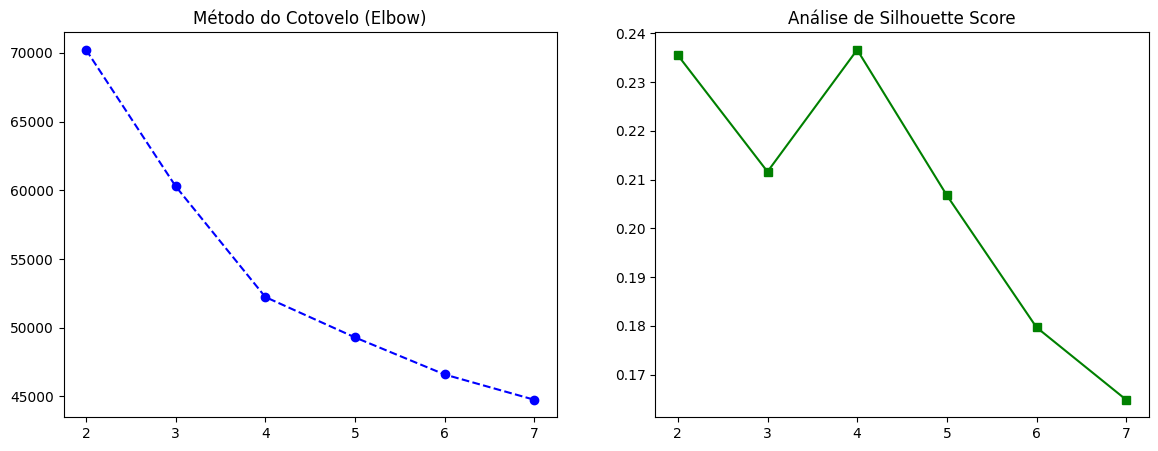

O melhor número de clusters (k) segundo o Silhouette é: 4

--- Teste de Estabilidade com diferentes Seeds (Para K=4) ---
Seed 0: Inércia = 52231.45
Seed 1: Inércia = 52231.45
Seed 2: Inércia = 52231.45
Seed 42: Inércia = 52231.45
Seed 100: Inércia = 52231.45

Modelo K-Means (k=4) treinado e salvo com sucesso!


In [7]:
# Preparação do DataFrame para o KMeans
df_kmeans_res = pd.DataFrame(X_res, columns=todas_colunas)

# Padronização APENAS nas colunas numéricas
scaler = StandardScaler()
df_kmeans_res[colunas_numericas_finais] = scaler.fit_transform(df_kmeans_res[colunas_numericas_finais])
X_kmeans_final = df_kmeans_res.values

# MÉTODO DO COTOVELO E SILHOUETTE
inercia = []
silhouette_scores = []
k_range = range(2, 8) 

print("Treinando o K-Means com dados balanceados...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_kmeans_final)
    
    inercia.append(kmeans.inertia_)
    sil_score = silhouette_score(X_kmeans_final, labels) 
    silhouette_scores.append(sil_score)

# Gráficos de Avaliação
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(k_range, inercia, marker='o', linestyle='--', color='b')
ax1.set_title('Método do Cotovelo (Elbow)')
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-', color='g')
ax2.set_title('Análise de Silhouette Score')
plt.show()

# ESCOLHA AUTOMÁTICA DO MELHOR K
melhor_k = k_range[np.argmax(silhouette_scores)]
print(f"O melhor número de clusters (k) segundo o Silhouette é: {melhor_k}")

# TESTE DE ESTABILIDADE (Para o K escolhido)
print(f"\n--- Teste de Estabilidade com diferentes Seeds (Para K={melhor_k}) ---")
seeds = [0, 1, 2, 42, 100]
for seed in seeds:
    kmeans_test = KMeans(n_clusters=melhor_k, random_state=seed, n_init=10)
    kmeans_test.fit(X_kmeans_final)
    print(f"Seed {seed}: Inércia = {kmeans_test.inertia_:.2f}")

# Treino final e salvamento
kmeans_final = KMeans(n_clusters=melhor_k, random_state=42, n_init=10).fit(X_kmeans_final)
joblib.dump(kmeans_final, 'modelo_kmeans_final.joblib')
print(f"\nModelo K-Means (k={melhor_k}) treinado e salvo com sucesso!")

In [8]:
# X_res deve ser o resultado do fit_resample anterior
df_kproto_res = pd.DataFrame(X_res, columns=todas_colunas)

# Padronização apenas nas numéricas
scaler = StandardScaler()
df_kproto_res[colunas_numericas_finais] = scaler.fit_transform(df_kproto_res[colunas_numericas_finais])

# Índices categóricos para o K-Prototypes 
indices_categoricos = [i for i, col in enumerate(todas_colunas) if col.startswith('cat__')]

# Treinar o K-Prototypes (não compensa rodar várias vezes igual o k-means por conta do custo computacional)
print("Treinando o K-Prototypes com base balanceada...")
kproto = KPrototypes(n_clusters=5, init='Cao', random_state=42, n_jobs=-1)

# Passar .values converte para matriz numpy
clusters_kproto = kproto.fit_predict(df_kproto_res.values, categorical=indices_categoricos)

# Salvar resultados
results_df = df_kproto_res.copy()
results_df['Cluster_KPrototypes'] = clusters_kproto
results_df['Anomalia'] = y_res # Incluindo o alvo balanceado para validar

print("Concluído! Clusterização realizada.")
joblib.dump({'modelo': kproto, 'indices': indices_categoricos}, 'modelo_proto_final.joblib')

Treinando o K-Prototypes com base balanceada...
Concluído! Clusterização realizada.


['modelo_proto_final.joblib']

In [9]:
# Como o K-Medoids não aceita bem colunas categóricas (diferente do K-Prototypes), 
# focamos nas numéricas ou no X_res completo (se ele for todo numérico).
X_medoids = pd.DataFrame(X_res, columns=todas_colunas)
X_num = X_medoids[colunas_numericas_finais]

# Padronização (O K-Medoids é sensível a escala)
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# Treinar o K-Medoids (não compensa rodar várias vezes igual k-means por conta do custo computacional)
print("Treinando o K-Medoids (PAM) com dados balanceados...")
kmedoids = KMedoids(n_clusters=5, random_state=42, init='k-medoids++')

# Treino
clusters_kmed = kmedoids.fit_predict(X_num_scaled)

# Salvar resultados
results_kmed = pd.DataFrame(X_num_scaled, columns=colunas_numericas_finais)
results_kmed['Cluster_KMedoides'] = clusters_kmed
results_kmed['Anomalia'] = y_res

print("Concluído! Clusters de K-Medoids criados com base balanceada.")
joblib.dump(kmedoids, 'modelo_kmedoids_final.joblib')

Treinando o K-Medoids (PAM) com dados balanceados...


Concluído! Clusters de K-Medoids criados com base balanceada.


['modelo_kmedoids_final.joblib']

In [10]:
print("Treinando o DBSCAN com dados balanceados...")

# Configuração do modelo
# Se o gráfico de cotovelo sugerir um valor diferente da para ajustar aqui
dbscan = DBSCAN(eps=1.1, min_samples=10, n_jobs=-1)

# Treino
clusters_dbscan = dbscan.fit_predict(X_kmeans_final)

# Verificação de resultados
# -1 representa o ruído
ruidos = (clusters_dbscan == -1).sum()
total_pontos = len(clusters_dbscan)

print(f"Concluído!")
print(f"Total de registros processados: {total_pontos}")
print(f"Transações classificadas como Ruído (potenciais anomalias): {ruidos}")
print(f"Porcentagem de anomalias detectadas: {(ruidos/total_pontos)*100:.2f}%")

# Salvar modelo
modelo_info = {
    'modelo': dbscan,
    'eps': 0.30,
    'min_samples': 10,
    'n_features': X_kmeans_final.shape[1]
}
joblib.dump(modelo_info, 'modelo_dbscan_euc_final.joblib')

Treinando o DBSCAN com dados balanceados...
Concluído!
Total de registros processados: 11880
Transações classificadas como Ruído (potenciais anomalias): 1911
Porcentagem de anomalias detectadas: 16.09%


['modelo_dbscan_euc_final.joblib']

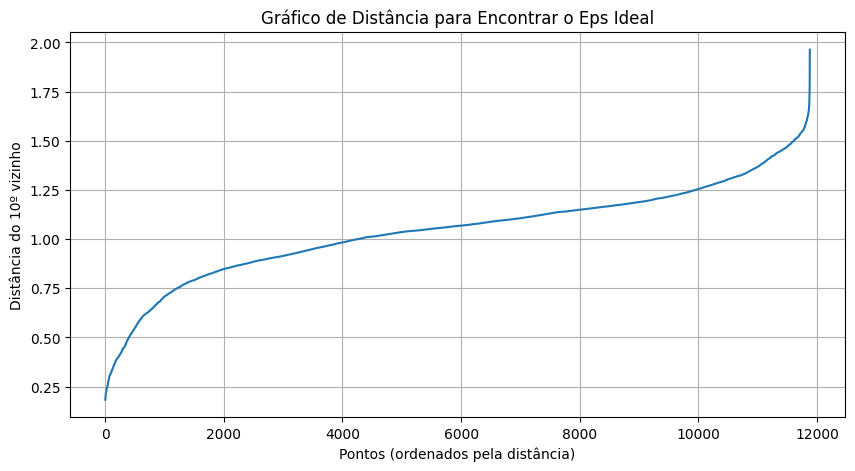

In [11]:
# Usaremos o K=10 (o mesmo min_samples)
neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(X_kmeans_final)
distances, indices = neighbors_fit.kneighbors(X_kmeans_final)

# Ordenar as distâncias médias
distances = np.sort(distances[:, 9], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('Gráfico de Distância para Encontrar o Eps Ideal')
plt.xlabel('Pontos (ordenados pela distância)')
plt.ylabel('Distância do 10º vizinho')
plt.grid(True)
plt.show()

In [12]:
# Preparação (usando as listas dinâmicas que criadas antes)
df_gower_res = pd.DataFrame(X_res, columns=todas_colunas)

# Padronização das numéricas
scaler = StandardScaler()
df_gower_res[colunas_numericas_finais] = scaler.fit_transform(df_gower_res[colunas_numericas_finais])

# Cálculo da matriz Gower
print("Calculando matriz Gower...")
matriz_distancia_res = gower.gower_matrix(df_gower_res)

# Treino
# O 'eps' na métrica Gower costuma ser bem menor que na Euclidiana
dbscan_gower = DBSCAN(eps=0.038, min_samples=10, metric='precomputed', n_jobs=-1)
clusters_gower = dbscan_gower.fit_predict(matriz_distancia_res)

# Persistência 
# Como o DBSCAN 'precomputed' não sabe como calcular a distância sozinho, 
# É necessário salvar o 'df_gower_res' de treino para comparar com novos dados depois.
modelo_gower ={
    'modelo': dbscan_gower,
    'dados_treino': df_gower_res
}
joblib.dump(modelo_gower, 'modelo_dbscan_gow_final.joblib')

print(f"Concluído! Foram isoladas {(clusters_gower == -1).sum()} anomalias.")

Calculando matriz Gower...
Concluído! Foram isoladas 3039 anomalias.


In [13]:
# Criar o DataFrame com X_res
results_if = pd.DataFrame(X_res, columns=todas_colunas)

# Ajuste de Contaminação
# A contaminação é a proporção de fraudes que você espera. 
iso_forest = IsolationForest(contamination=0.29, random_state=42, n_jobs=-1)

# Treino
print("Treinando o Isolation Forest com base balanceada...")
preds = iso_forest.fit_predict(results_if)

# Salvar resultados
results_if['Cluster_IF'] = preds
results_if['Anomalia'] = y_res

# Verificação
anomalias_if = (preds == -1).sum()
print(f"Detectadas {anomalias_if} anomalias pelo Isolation Forest.")

# Salvar modelo
joblib.dump(iso_forest, 'modelo_iforest_final.joblib')

Treinando o Isolation Forest com base balanceada...
Detectadas 3445 anomalias pelo Isolation Forest.


['modelo_iforest_final.joblib']

In [14]:
# CARREGAMENTO DOS MODELOS SALVOS
modelo_kproto = joblib.load('modelo_proto_final.joblib')
dbscan_gow_data = joblib.load('modelo_dbscan_gow_final.joblib')

# DEFINIÇÃO DO PAINEL DE CONTROLE
modelos_e_testes = {
    "K-Means": {"func": joblib.load('modelo_kmeans_final.joblib'), "data": X_kmeans_final, "type": "spatial"},
    "K-Medóides": {"func": joblib.load('modelo_kmedoids_final.joblib'), "data": X_num_scaled, "type": "spatial"},
    "K-Prototypes": {"func": modelo_kproto['modelo'], "data": df_kproto_res, "type": "mixed"},
    "DBSCAN (Euc)": {"func": modelo_info['modelo'], "data": X_kmeans_final, "type": "density"},
    "DBSCAN (Gower)": {"func": modelo_gower['modelo'], "data": matriz_distancia_res, "type": "density"},
    "Isolation Forest": {"func": joblib.load('modelo_iforest_final.joblib'), "data": results_if, "type": "tree"}
}

print("VALIDAÇÃO TÉCNICA: ")

# LOOP DE COMPARAÇÃO
previsoes_armazenadas = {}
for nome, m in modelos_e_testes.items():
    # Treino/Predição
    if nome == "K-Prototypes":
        labels = m["func"].fit_predict(m["data"].values, categorical=indices_categoricos)
    else:
        labels = m["func"].fit_predict(m["data"])
    previsoes_armazenadas[nome] = labels
    
    # Métricas de Coesão (Apenas para modelos espaciais)
    if m["type"] == "spatial":
        sil = silhouette_score(m["data"], labels)
        db = davies_bouldin_score(m["data"], labels)
        print(f"[{nome}] Sil: {sil:.3f} | DB: {db:.3f}")
    else:
        print(f"[{nome}] Métricas de coesão espacial: Não aplicável.")
        
    # Estabilidade ARI (Exceto modelos determinísticos)
    if nome not in ["DBSCAN (Euc)", "DBSCAN (Gower)"]:
        seeds = [0, 1, 2, 42, 100]
        labels_list = []
        
        for s in seeds:
            m["func"].set_params(random_state=s)
            if nome == "K-Prototypes":
                lbl = m["func"].fit_predict(m["data"].values, categorical=indices_categoricos)
            else:
                lbl = m["func"].fit_predict(m["data"])
            labels_list.append(lbl)
        
        # Média do ARI
        ari_total = sum(adjusted_rand_score(labels_list[i], labels_list[j]) 
                        for i in range(len(labels_list)) 
                        for j in range(i + 1, len(labels_list)))
        count = len(labels_list) * (len(labels_list) - 1) / 2
        print(f"    -> Estabilidade (ARI Médio): {ari_total / count:.3f}")
    else:
        print(f"    -> Estabilidade (ARI): Determinístico (Não aplicável).")

print("\n--- Processo Concluído ---")

VALIDAÇÃO TÉCNICA: 
[K-Means] Sil: 0.237 | DB: 1.564
    -> Estabilidade (ARI Médio): 1.000
[K-Medóides] Sil: 0.287 | DB: 1.471
    -> Estabilidade (ARI Médio): 0.807
[K-Prototypes] Métricas de coesão espacial: Não aplicável.
    -> Estabilidade (ARI Médio): 0.938
[DBSCAN (Euc)] Métricas de coesão espacial: Não aplicável.
    -> Estabilidade (ARI): Determinístico (Não aplicável).
[DBSCAN (Gower)] Métricas de coesão espacial: Não aplicável.
    -> Estabilidade (ARI): Determinístico (Não aplicável).
[Isolation Forest] Métricas de coesão espacial: Não aplicável.
    -> Estabilidade (ARI Médio): 0.807

--- Processo Concluído ---


--- K-Means ---
Acurácia: 76.50% | Precisão: 31.61% | Recall: 35.25% | F1-Score: 33.33%

--- K-Medóides ---
Acurácia: 76.11% | Precisão: 30.16% | Recall: 32.93% | F1-Score: 31.48%

--- K-Prototypes ---
Acurácia: 76.34% | Precisão: 31.02% | Recall: 34.29% | F1-Score: 32.57%

--- DBSCAN (Euc) ---
Acurácia: 67.97% | Precisão: 2.25% | Recall: 2.17% | F1-Score: 2.21%

--- DBSCAN (Gower) ---
Acurácia: 78.68% | Precisão: 40.90% | Recall: 62.78% | F1-Score: 49.53%

--- Isolation Forest ---
Acurácia: 74.72% | Precisão: 35.15% | Recall: 61.16% | F1-Score: 44.65%



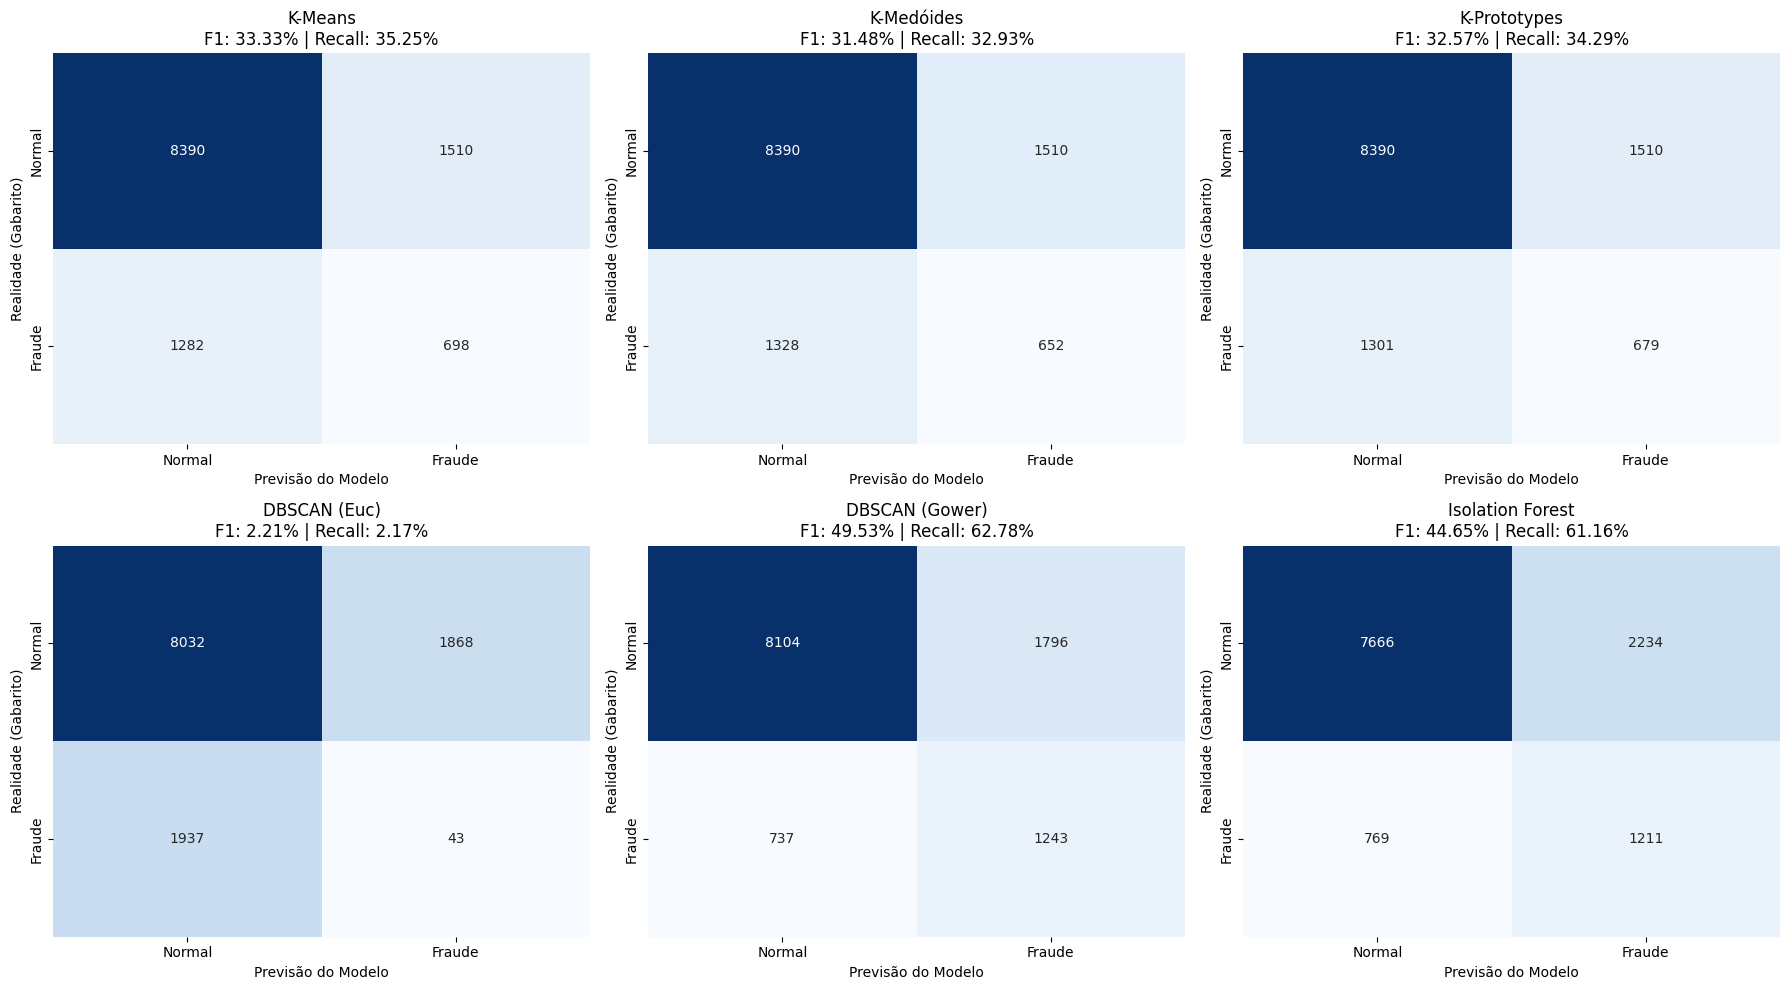

In [15]:
# Performance e Gráficos

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
gabarito = y_res 

# Iterar sobre os nomes dos modelos 
for i, nome in enumerate(['K-Means', 'K-Medóides', 'K-Prototypes', 'DBSCAN (Euc)', 'DBSCAN (Gower)', 'Isolation Forest']):
    
    # Puxa o resultado que já está na memória da Célula 1
    previsoes = previsoes_armazenadas[nome] 
    
    # Identificar fraudes
    if "DBSCAN" in nome or "Isolation" in nome:
        previsoes_finais = (previsoes == -1).astype(int)
    else:
        temp_df = pd.DataFrame({'cluster': previsoes, 'real': gabarito})
        taxa_fraude = temp_df.groupby('cluster')['real'].mean()
        cluster_suspeito = taxa_fraude.idxmax()
        previsoes_finais = (previsoes == cluster_suspeito).astype(int)

    # Cálculo das métricas
    acc = accuracy_score(gabarito, previsoes_finais)
    prec = precision_score(gabarito, previsoes_finais, zero_division=0)
    rec = recall_score(gabarito, previsoes_finais)
    f1 = f1_score(gabarito, previsoes_finais)

    # Impressão no Console
    print(f"--- {nome} ---")
    print(f"Acurácia: {acc*100:.2f}% | Precisão: {prec*100:.2f}% | Recall: {rec*100:.2f}% | F1-Score: {f1*100:.2f}%\n")

    # Heatmap (Matriz de Confusão)
    cm = confusion_matrix(gabarito, previsoes_finais)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Normal', 'Fraude'], yticklabels=['Normal', 'Fraude'], cbar=False)
    
    axes[i].set_title(f'{nome}\nF1: {f1*100:.2f}% | Recall: {rec*100:.2f}%')
    axes[i].set_ylabel('Realidade (Gabarito)')
    axes[i].set_xlabel('Previsão do Modelo')

plt.tight_layout()
plt.show()

In [16]:
print("Iniciando a extração de Regras de Negócio com o Apriori na base pós-SMOTE...\n")

# Recriando o DataFrame unificado a partir da base balanceada (SMOTE)
df_res = pd.DataFrame(X_res, columns=todas_colunas)
df_res['Anomalia'] = y_res

# Mapeamento dinâmico das colunas categóricas para evitar erros de nomenclatura do OneHotEncoder
col_madrugada = [c for c in todas_colunas if 'Madrugada' in c][0]
col_redondo = [c for c in todas_colunas if 'Valor_Redondo' in c][0]
col_pendente = [c for c in todas_colunas if 'Status_Pendente' in c][0]
col_banco = [c for c in todas_colunas if 'Mesmo_Banco' in c][0]

# Discretização usando as colunas numéricas da base SMOTE
df_res['Valor_Baixo'] = (df_res['num__Valor'] < 2000).astype(int)
df_res['Hora_Noite'] = (df_res['num__Hora'] < 18).astype(int) # Ajustado para manter lógica numérica coerente

colunas_regra = [
    col_madrugada, col_redondo, 'Valor_Baixo', 'Hora_Noite', 
    col_pendente, col_banco, 'Anomalia'
]

# Converter para booleano (exigência do mlxtend)
df_apriori = df_res[colunas_regra].astype(bool)

# Mineração de Padrões Frequentes (Ajustamos o suporte já que a classe agora representa ~16.6% da base)
padroes = apriori(df_apriori, min_support=0.01, use_colnames=True)

# Gerar Regras
regras = association_rules(padroes, metric="confidence", min_threshold=0.02)

# Filtrar apenas as regras onde o RESULTADO (consequent) é estritamente Anomalia
regras_fraude = regras[regras['consequents'] == frozenset({'Anomalia'})]

# Pegar estritamente as 3 melhores regras
top_3_regras = regras_fraude.sort_values(by='confidence', ascending=False).head(3)

print(f"Focando a análise nas 3 regras de maior risco (Top 3) na base balanceada:")
for i, row in top_3_regras.iterrows():
    antecedentes = " E ".join(list(row['antecedents']))
    confianca = row['confidence'] * 100
    lift = row['lift']
    print(f"SE [{antecedentes}] ENTÃO é Fraude (Confiança: {confianca:.2f}% | Multiplicador de Risco: {lift:.2f})")

Iniciando a extração de Regras de Negócio com o Apriori na base pós-SMOTE...

Focando a análise nas 3 regras de maior risco (Top 3) na base balanceada:
SE [Valor_Baixo E cat__Valor_Redondo_1 E Hora_Noite E cat__Status_Pendente_1] ENTÃO é Fraude (Confiança: 94.76% | Multiplicador de Risco: 5.69)
SE [Valor_Baixo E cat__Valor_Redondo_1 E cat__Status_Pendente_1] ENTÃO é Fraude (Confiança: 92.61% | Multiplicador de Risco: 5.56)
SE [Valor_Baixo E cat__Valor_Redondo_1 E Hora_Noite] ENTÃO é Fraude (Confiança: 91.77% | Multiplicador de Risco: 5.51)



Iniciando a otimização...

Calculando matriz Gower para as novas dimensões...
Otimização concluída! Todos os 6 modelos coletados e sincronizados.
--- K-Means ---
Acurácia: 72.04% | Precisão: 23.62% | Recall: 30.35% | F1-Score: 26.57%

--- K-Medóides ---
Acurácia: 72.04% | Precisão: 23.62% | Recall: 30.35% | F1-Score: 26.57%

--- K-Prototypes ---
Acurácia: 74.92% | Precisão: 30.75% | Recall: 40.30% | F1-Score: 34.89%

--- DBSCAN (Euclidiana) ---
Acurácia: 83.07% | Precisão: 44.60% | Recall: 6.46% | F1-Score: 11.29%

--- DBSCAN (Gower) ---
Acurácia: 83.93% | Precisão: 70.52% | Recall: 6.16% | F1-Score: 11.33%

--- Isolation Forest ---
Acurácia: 80.99% | Precisão: 43.12% | Recall: 43.99% | F1-Score: 43.55%



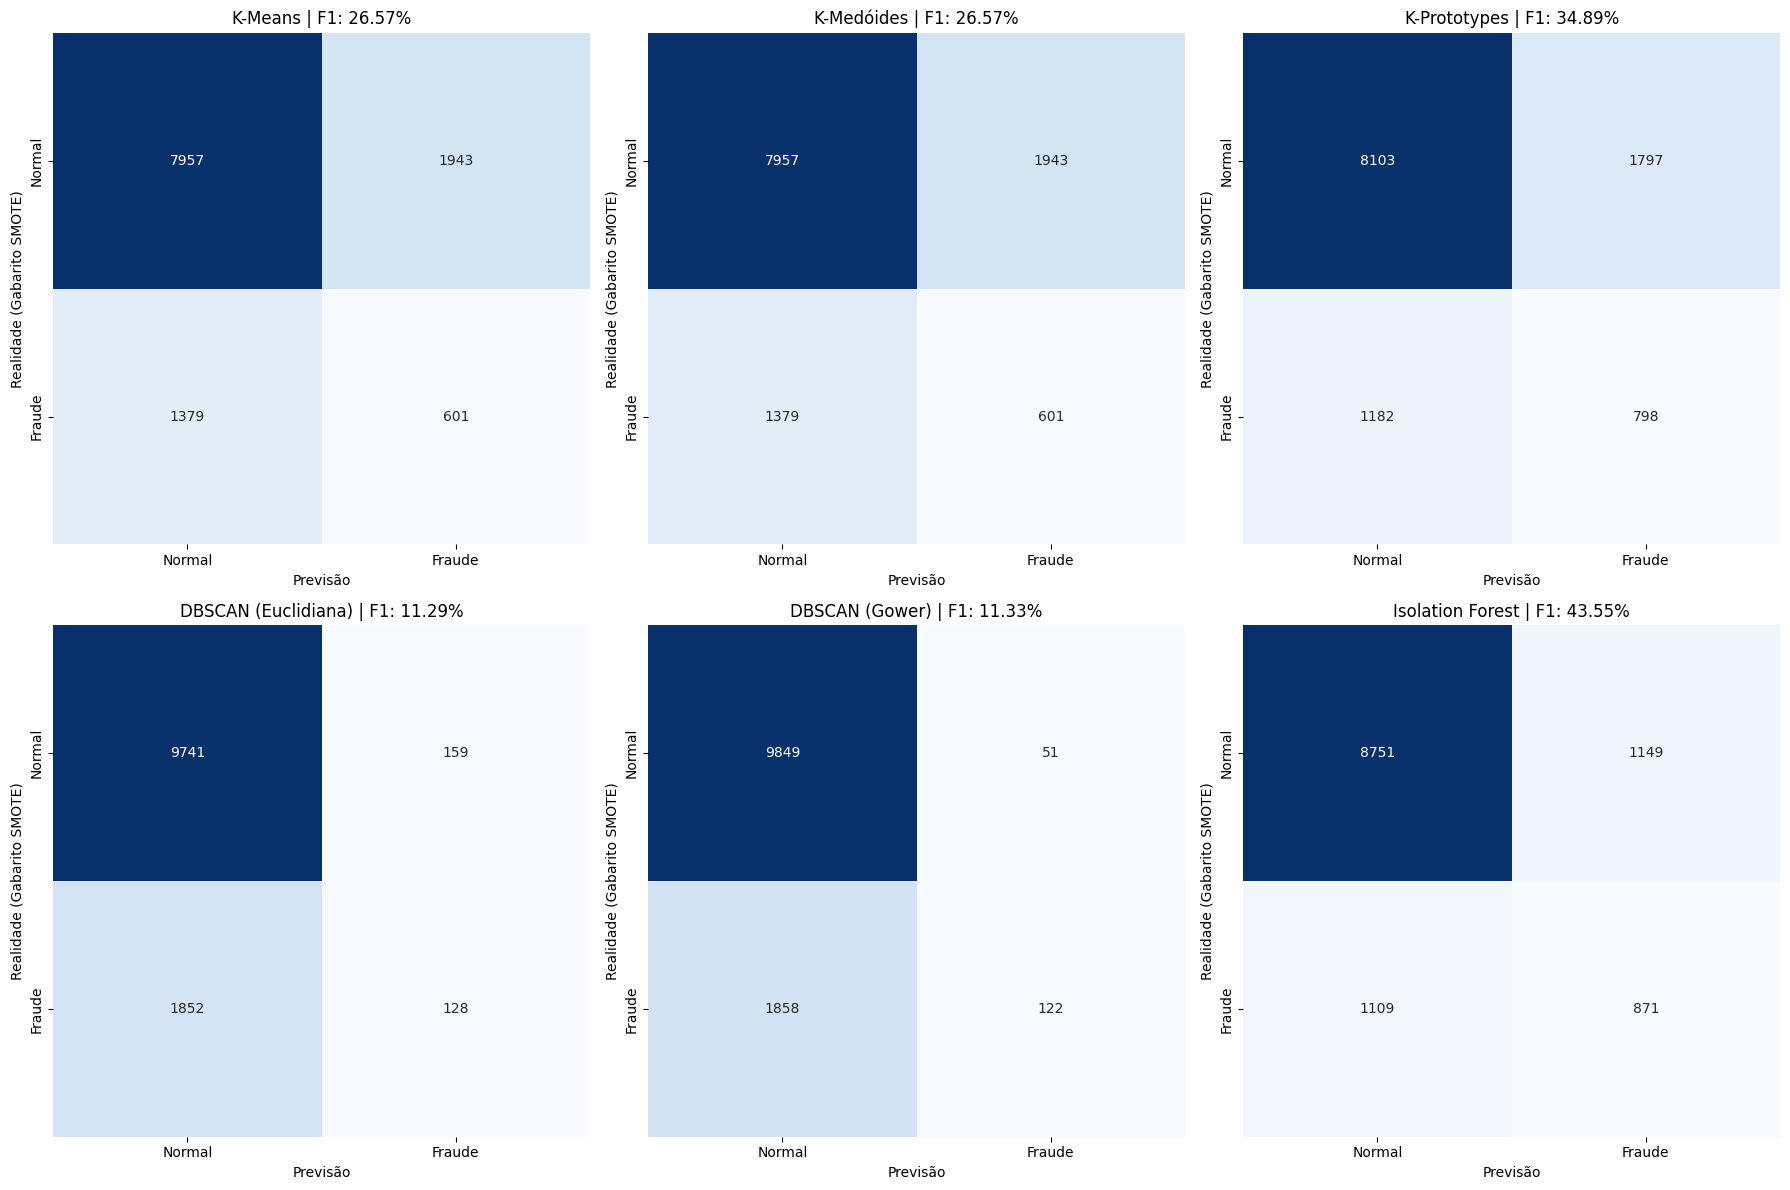

In [24]:
# INJEÇÃO DE CONHECIMENTO 
df_res['Regra_ValorBaixo'] = (df_res['num__Valor'] < 2000).astype(int)
df_res['Regra_HoraNoite'] = (df_res['num__Hora'] < 18).astype(int)
df_res['Regra_StatusPendente'] = df_res[col_pendente].astype(int)

var_num_atualizado = colunas_numericas_finais + ['Regra_ValorBaixo', 'Regra_HoraNoite', 'Regra_StatusPendente']

# Padronização das numéricas 
scaler = StandardScaler()
X_num_pad = scaler.fit_transform(df_res[var_num_atualizado])
peso_regras = 10
X_num_pad[:, -3:] = X_num_pad[:, -3:] * peso_regras

colunas_categoricas_enc = [c for c in df_res.columns if c.startswith('cat__')]
colunas_features_todas = var_num_atualizado + colunas_categoricas_enc
X_completo_modelos = df_res[colunas_features_todas].values

print("\nIniciando a otimização...\n")

gabarito = df_res['Anomalia']

# Definição dos Espaços de Busca
grids = {
    'KMeans': {'n_clusters': [5, 10, 20, 30, 40, 50]},
    'DBSCAN': {'eps': [0.8, 1.0, 1.5, 2.0, 2.5], 'min_samples': [3, 5, 10, 15]},
    'IsolationForest': {'contamination': [0.16, 0.165, 0.17], 'n_estimators': [100, 200, 500], 'max_features': [0.5, 0.7, 1.0], 'bootstrap': [True]}
}

# Otimização do KMeans
best_f1_km, best_params_km = -1, {}
for params in ParameterGrid(grids['KMeans']):
    model = KMeans(**params, random_state=42, n_init=10).fit(X_num_pad)
    labels = model.labels_
    taxa_fraude = pd.Series(labels, name='c').to_frame().join(gabarito.rename('a')).groupby('c')['a'].mean()
    pred = (labels == taxa_fraude.idxmax()).astype(int)
    f1 = f1_score(gabarito, pred)
    if f1 > best_f1_km: best_f1_km, best_params_km = f1, params
df_res['Cluster_KMeans'] = KMeans(**best_params_km, random_state=42, n_init=10).fit_predict(X_num_pad)

# Otimização do DBSCAN Euclidiano
best_f1_db, best_params_db = -1, {}
for params in ParameterGrid(grids['DBSCAN']):
    pred = DBSCAN(**params).fit_predict(X_num_pad)
    f1 = f1_score(gabarito, (pred == -1).astype(int))
    if f1 > best_f1_db: best_f1_db, best_params_db = f1, params
df_res['Cluster_DBSCAN'] = DBSCAN(**best_params_db).fit_predict(X_num_pad)

# Otimização do Isolation Forest
best_f1_if, best_params_if = -1, {}
for params in ParameterGrid(grids['IsolationForest']):
    pred = IsolationForest(**params, random_state=42, n_jobs=-1).fit_predict(X_completo_modelos)
    f1 = f1_score(gabarito, (pred == -1).astype(int))
    if f1 > best_f1_if: best_f1_if, best_params_if = f1, params
df_res['Cluster_IsolationForest'] = IsolationForest(**best_params_if, random_state=42, n_jobs=-1).fit_predict(X_completo_modelos)

# DBSCAN Gower
print("Calculando matriz Gower para as novas dimensões...")
matriz_gower_res = gower.gower_matrix(df_res[colunas_features_todas])
df_res['Cluster_DBSCAN_Gower'] = DBSCAN(eps=0.07, min_samples=5, metric='precomputed', n_jobs=-1).fit_predict(matriz_gower_res)

# KMedoids
df_res['Cluster_KMedoides'] = KMedoids(n_clusters=5, random_state=42, init='k-medoids++').fit_predict(X_num_pad)

# KPrototypes
indices_cat_kproto = [colunas_features_todas.index(c) for c in colunas_categoricas_enc + ['Regra_ValorBaixo', 'Regra_HoraNoite', 'Regra_StatusPendente']]
df_res['Cluster_KPrototypes'] = KPrototypes(n_clusters=5, init='Cao', random_state=42, n_jobs=-1).fit_predict(X_completo_modelos, categorical=indices_cat_kproto)

print("Otimização concluída! Todos os 6 modelos coletados e sincronizados.")

# COMPARATIVO VISUAL
colunas_modelos = [
    'Cluster_KMeans', 'Cluster_KMedoides', 'Cluster_KPrototypes', 
    'Cluster_DBSCAN', 'Cluster_DBSCAN_Gower', 'Cluster_IsolationForest'
]
nomes_modelos = [
    'K-Means', 'K-Medóides', 'K-Prototypes', 
    'DBSCAN (Euclidiana)', 'DBSCAN (Gower)', 'Isolation Forest'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(colunas_modelos):
    if 'DBSCAN' in col or 'IsolationForest' in col:
        previsoes = (df_res[col] == -1).astype(int)
    else:
        taxa_fraude = df_res.groupby(col)['Anomalia'].mean()
        cluster_suspeito = taxa_fraude.idxmax()
        previsoes = (df_res[col] == cluster_suspeito).astype(int)

    acc = accuracy_score(gabarito, previsoes)
    prec = precision_score(gabarito, previsoes, zero_division=0)
    rec = recall_score(gabarito, previsoes)
    f1 = f1_score(gabarito, previsoes)

    print(f"--- {nomes_modelos[i]} ---")
    print(f"Acurácia: {acc*100:.2f}% | Precisão: {prec*100:.2f}% | Recall: {rec*100:.2f}% | F1-Score: {f1*100:.2f}%\n")

    cm = confusion_matrix(gabarito, previsoes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Normal', 'Fraude'], yticklabels=['Normal', 'Fraude'], cbar=False)
    axes[i].set_title(f'{nomes_modelos[i]} | F1: {f1*100:.2f}%')
    axes[i].set_ylabel('Realidade (Gabarito SMOTE)')
    axes[i].set_xlabel('Previsão')

plt.tight_layout()
plt.show()

In [18]:
padroes_fp = fpgrowth(df_apriori, min_support=0.02, use_colnames=True)
regras_fp = association_rules(padroes_fp, metric="confidence", min_threshold=0.02)
regras_fraude_fp = regras_fp[regras_fp['consequents'] == frozenset({'Anomalia'})]

print("\nTop 3 Regras do FP-Growth (Consequente: Anomalia):")
print(regras_fraude_fp.sort_values(by='confidence', ascending=False).head(3))


Top 3 Regras do FP-Growth (Consequente: Anomalia):
                                         antecedents consequents  \
185  (Valor_Baixo, cat__Valor_Redondo_1, Hora_Noite)  (Anomalia)   
172              (Valor_Baixo, cat__Valor_Redondo_1)  (Anomalia)   
178               (cat__Valor_Redondo_1, Hora_Noite)  (Anomalia)   

     antecedent support  consequent support   support  confidence      lift  \
185            0.034764            0.166667  0.031902    0.917676  5.506053   
172            0.038131            0.166667  0.034343    0.900662  5.403974   
178            0.039394            0.166667  0.032407    0.822650  4.935897   

     representativity  leverage  conviction  zhangs_metric   jaccard  \
185               1.0  0.026108   10.122549       0.847857  0.188183   
172               1.0  0.027988    8.388889       0.847258  0.201481   
178               1.0  0.025842    4.698795       0.830104  0.186621   

     certainty  kulczynski  
185   0.901211    0.554545  
172   0.880